## 1) Calculations in AiiDAlab (with LSMO)

For adsorption studies, AiiDAlab provides automated workflows such as:

1. **Gas adsorption isotherms**  
   - Grand Canonical Monte Carlo (GCMC) simulations to compute uptake as a function of pressure and temperature.

2. **Henry’s coefficients**  
   - Low-pressure adsorption constants, useful for estimating selectivity.

3. **Pore analysis**  
   - Helium void fraction, accessible pore volume, and surface area to characterize adsorption capacity.

4. **Density calculations**  
   - Determination of framework or surface density, providing a structural descriptor linked to adsorption performance.

These tools can be applied both to porous frameworks and to surfaces like **LSMO**, supporting adsorption studies across materials classes.


2) We performed a pore analysis of IRMOF-1, with a probe radius of 1.525 Angstrom. We obtained as follows:
density: 0.576983 g/cm^3
ASA_A^2: 3964.65 A^2
POAV: 13737.4 A^3
porosity or POAV_Volume_fraction: 0.77498

pk: 5

## 3) Henry coefficients
We performed isotherm calculations for both CO₂ and CH₄ at 300 K and obtained the Henry coefficients:

- **Henry coefficient CO₂** = 5.0 × 10⁻⁶ mol/kg/Pa  
  pK: 294

- **Henry coefficient CH₄** = 1.0 × 10⁻⁶ mol/kg/Pa  
  pK: 329

The Henry coefficients indicate the relative affinity of gases for the adsorbent at low pressures. At 300 K, CO₂ has a higher Henry coefficient than CH₄. This clearly shows that CO₂ molecules interact more strongly with the IRMOF-1 framework than CH₄ molecules. As a result, IRMOF-1 preferentially adsorbs CO₂ in the low-pressure regime, making it effective for separating CO₂ from CH₄ in mixtures such as biogas.

## 4) Pure Isotherms at 300K
 
pk: 373 (CO2), pk: 391 (CH4)

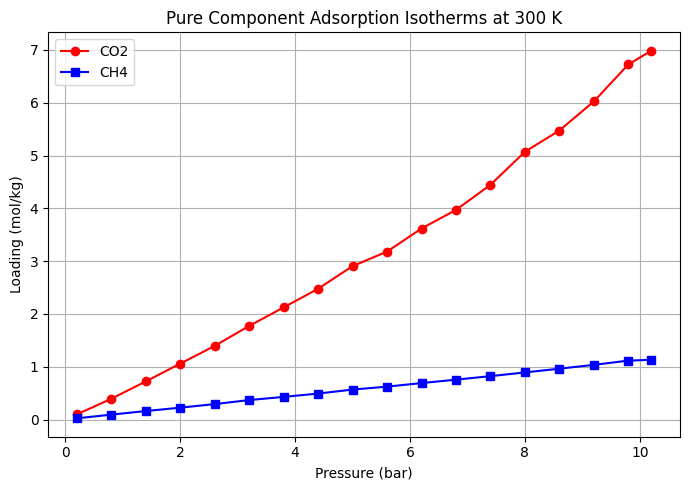

In [2]:
import matplotlib.pyplot as plt

# --- CO2 data ---
pressures_co2 = [0.2, 0.8, 1.4, 2.0, 2.6, 3.2, 3.8, 4.4, 5.0, 5.6, 6.2, 6.8, 7.4, 8.0, 8.6, 9.2, 9.8, 10.2]
loadings_co2 = [0.096723227554076, 0.39315949765796, 0.72151212791768, 1.0585987498258,
                1.394516510398, 1.7729353678762, 2.1233340216647, 2.4769795124972,
                2.9052697869712, 3.180276884598, 3.6175608976839, 3.9693881597718,
                4.4454069387926, 5.0707152850966, 5.4735178887752, 6.0242463881785,
                6.7247839487919, 6.985050406239]

# --- CH4 data ---
pressures_ch4 = [0.2, 0.8, 1.4, 2.0, 2.6, 3.2, 3.8, 4.4, 5.0, 5.6, 6.2, 6.8, 7.4, 8.0, 8.6, 9.2, 9.8, 10.2]
loadings_ch4 = [0.022050587171492, 0.09259979249488, 0.1602314081214, 0.22409669277688,
                0.29208546047824, 0.36825625753048, 0.4280954642514, 0.49127891312764,
                0.56676787440064, 0.62264593992788, 0.68988793510192, 0.75479220761868,
                0.82125496190936, 0.89164638902328, 0.96239496821204, 1.034929307775,
                1.1151856511322, 1.1304512536095]

# --- Plot both isotherms ---
plt.figure(figsize=(7,5))
plt.plot(pressures_co2, loadings_co2, marker="o", linestyle="-", color="red", label="CO2")
plt.plot(pressures_ch4, loadings_ch4, marker="s", linestyle="-", color="blue", label="CH4")

plt.xlabel("Pressure (bar)")
plt.ylabel("Loading (mol/kg)")
plt.title("Pure Component Adsorption Isotherms at 300 K")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 5) Binary mixture isotherms

                      Component 1: p^0 = 10.780930 > 10.200000, the highest pressure
                      exhibited in the pure-component isotherm data. Thus,
                      pyIAST had to extrapolate the isotherm data to achieve
                      this IAST result.


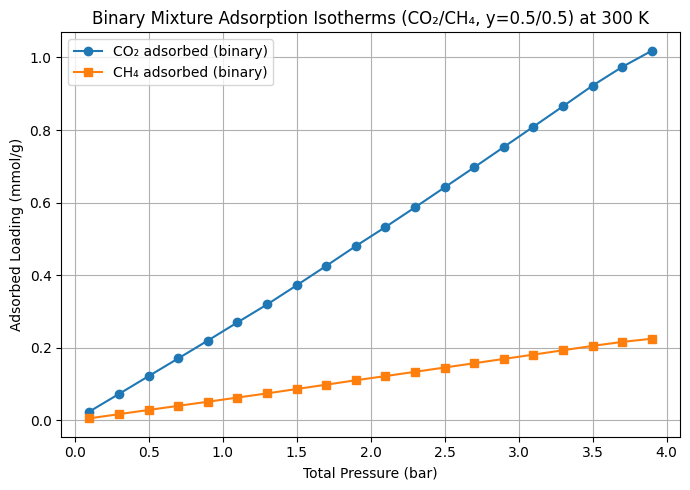

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyiast

# --- CO2 data ---
df_co2 = pd.DataFrame({
    "Pressure(bar)": [0.2, 0.8, 1.4, 2.0, 2.6, 3.2, 3.8, 4.4, 5.0, 5.6, 6.2, 6.8, 7.4, 8.0, 8.6, 9.2, 9.8, 10.2],
    "Loading(mmol/g)": [0.096723227554076, 0.39315949765796, 0.72151212791768, 1.0585987498258,
                        1.394516510398, 1.7729353678762, 2.1233340216647, 2.4769795124972,
                        2.9052697869712, 3.180276884598, 3.6175608976839, 3.9693881597718,
                        4.4454069387926, 5.0707152850966, 5.4735178887752, 6.0242463881785,
                        6.7247839487919, 6.985050406239]
})

# --- CH4 data ---
df_ch4 = pd.DataFrame({
    "Pressure(bar)": [0.2, 0.8, 1.4, 2.0, 2.6, 3.2, 3.8, 4.4, 5.0, 5.6, 6.2, 6.8, 7.4, 8.0, 8.6, 9.2, 9.8, 10.2],
    "Loading(mmol/g)": [0.022050587171492, 0.09259979249488, 0.1602314081214, 0.22409669277688,
                        0.29208546047824, 0.36825625753048, 0.4280954642514, 0.49127891312764,
                        0.56676787440064, 0.62264593992788, 0.68988793510192, 0.75479220761868,
                        0.82125496190936, 0.89164638902328, 0.96239496821204, 1.034929307775,
                        1.1151856511322, 1.1304512536095]
})

# --- Build interpolated isotherms with safe extrapolation at high P ---
co2_iso = pyiast.InterpolatorIsotherm(df_co2,
                                      pressure_key="Pressure(bar)",
                                      loading_key="Loading(mmol/g)",
                                      fill_value=df_co2["Loading(mmol/g)"].iloc[-1])

ch4_iso = pyiast.InterpolatorIsotherm(df_ch4,
                                      pressure_key="Pressure(bar)",
                                      loading_key="Loading(mmol/g)",
                                      fill_value=df_ch4["Loading(mmol/g)"].iloc[-1])

# --- Define mixture conditions ---
y = [0.5, 0.5]   # equimolar CO2/CH4 gas phase
P_vals = np.arange(0.1, 4.0 + 1e-8, 0.2)

n_co2, n_ch4 = [], []

for P in P_vals:
    n_mix = pyiast.iast([y[0]*P, y[1]*P], [co2_iso, ch4_iso])
    n_co2.append(n_mix[0])
    n_ch4.append(n_mix[1])

# --- Plot binary isotherms ---
plt.figure(figsize=(7,5))
plt.plot(P_vals, n_co2, marker="o", label="CO₂ adsorbed (binary)")
plt.plot(P_vals, n_ch4, marker="s", label="CH₄ adsorbed (binary)")
plt.xlabel("Total Pressure (bar)")
plt.ylabel("Adsorbed Loading (mmol/g)")
plt.title("Binary Mixture Adsorption Isotherms (CO₂/CH₄, y=0.5/0.5) at 300 K")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
